In [1]:
# Environment setup

import os
from pathlib import Path

LOCAL_DATA_DIR = Path(os.environ.get("LOCAL_DATA_DIR", Path.cwd())).resolve()
print(f"LOCAL_DATA_DIR set to {LOCAL_DATA_DIR}")

LOCAL_DATA_DIR set to /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle


In [2]:
# Imports

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
# Load datasets

DATA_DIR = LOCAL_DATA_DIR
print(f"Loading datasets from {DATA_DIR}")

data_df = pd.read_csv(DATA_DIR / "data.csv")
predict_df = pd.read_csv(DATA_DIR / "predict.csv")

print(f"Training data shape: {data_df.shape}")
print(f"Prediction data shape: {predict_df.shape}")

display(data_df.head())
display(predict_df.head())

Loading datasets from /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle
Training data shape: (1812, 51)
Prediction data shape: (453, 45)


,yearID,teamID,G,R,AB,H,2B,3B,HR,BB,...,decade_1970,decade_1980,decade_1990,decade_2000,decade_2010,W,ID,year_label,decade_label,win_bins
0,1935,BOS,154,718,5288,1458,281,63,69,609,...,False,False,False,False,False,78,317,1935,1930s,3
1,1993,TEX,162,835,5510,1472,284,39,181,483,...,False,False,True,False,False,86,2162,1993,1990s,3
2,2016,SEA,162,768,5583,1446,251,17,223,506,...,False,False,False,False,True,86,1895,2016,2010s,3
3,1938,CHN,154,713,5333,1435,242,70,65,522,...,False,False,False,False,False,89,428,1938,1930s,3
4,1996,BOS,162,928,5756,1631,308,31,209,642,...,False,False,True,False,False,85,375,1996,1990s,3


,G,R,AB,H,2B,3B,HR,BB,SO,SB,...,decade_1930,decade_1940,decade_1950,decade_1960,decade_1970,decade_1980,decade_1990,decade_2000,decade_2010,ID
0,157,588,5221,1340,199,57,110,383,752.0,24,...,False,False,True,False,False,False,False,False,False,1756
1,161,707,5417,1353,215,40,167,597,840.0,47,...,False,False,False,True,False,False,False,False,False,1282
2,162,743,5494,1381,234,37,197,658,923.0,41,...,False,False,False,True,False,False,False,False,False,351
3,156,828,5451,1578,340,66,84,577,641.0,49,...,True,False,False,False,False,False,False,False,False,421
4,162,818,5595,1494,284,35,208,587,1052.0,71,...,False,False,False,False,False,False,False,True,False,57


In [4]:
# Configuration aligned to the improved production pipeline

TARGET = "W"

EXCLUDED_COLUMNS = {
    "W",            # target
    "ID",           # row identifier
    "win_bins",     # target-derived bucket; leakage risk
    "year_label",   # duplicate metadata
    "decade_label", # duplicate metadata
}

# These three were verified as safe to drop for the tuned ElasticNet model
# used on this exact dataset. They had zero coefficient in the fitted model.
SAFE_DROP_COLUMNS = ["SO", "ER", "HRA"]

BEST_ALPHA = 0.01
BEST_L1_RATIO = 0.9
N_SPLITS = 5

In [5]:
# Feature selection and schema validation

def build_feature_list(train_df: pd.DataFrame, pred_df: pd.DataFrame) -> list[str]:
    shared = [c for c in train_df.columns if c in pred_df.columns]
    features = [
        c for c in shared
        if c not in EXCLUDED_COLUMNS and c not in SAFE_DROP_COLUMNS
    ]
    return features

def validate_schema(df: pd.DataFrame, expected_columns: list[str], dataset_name: str = "dataset") -> pd.DataFrame:
    current = list(df.columns)
    extra = [c for c in current if c not in expected_columns]
    missing = [c for c in expected_columns if c not in current]

    if extra:
        print(f"{dataset_name}: dropping unexpected columns: {extra}")
        df = df.drop(columns=extra, errors="ignore")

    if missing:
        print(f"{dataset_name}: adding missing columns with 0: {missing}")
        for col in missing:
            df[col] = 0

    return df.reindex(columns=expected_columns, fill_value=0)

feature_cols = build_feature_list(data_df, predict_df)

print(f"Number of modeling features: {len(feature_cols)}")
print("Dropped permanently with no impact for this tuned model:", SAFE_DROP_COLUMNS)

X = data_df[feature_cols].copy()
y = data_df[TARGET].copy()
X_predict = predict_df[feature_cols].copy()

X = validate_schema(X, feature_cols, "train")
X_predict = validate_schema(X_predict, feature_cols, "predict")

print(f"X shape: {X.shape}")
print(f"X_predict shape: {X_predict.shape}")

Number of modeling features: 41
Dropped permanently with no impact for this tuned model: ['SO', 'ER', 'HRA']
X shape: (1812, 41)
X_predict shape: (453, 41)


In [6]:
# Tuned ElasticNet model

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=BEST_ALPHA, l1_ratio=BEST_L1_RATIO, max_iter=10000)),
])

print(model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 ElasticNet(alpha=0.01, l1_ratio=0.9, max_iter=10000))])


In [7]:
# Time-aware cross-validation

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

mae_scores = []
rmse_scores = []
r2_scores = []

last_y_test = None
last_preds = None

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold}: MAE={mae:.5f}, RMSE={rmse:.5f}, R^2={r2:.5f}")

    last_y_test = y_test
    last_preds = preds

Fold 1: MAE=2.91705, RMSE=3.77896, R^2=0.92398
Fold 2: MAE=2.65123, RMSE=3.27536, R^2=0.93060
Fold 3: MAE=2.82849, RMSE=3.63281, R^2=0.93053
Fold 4: MAE=2.80078, RMSE=3.59052, R^2=0.91627
Fold 5: MAE=2.80539, RMSE=3.47789, R^2=0.93309


In [8]:
# Cross-validation summary and final fit

print("ElasticNet Performance (TimeSeriesSplit):")
print(f"  MAE :  {np.mean(mae_scores):.5f}")
print(f"  RMSE:  {np.mean(rmse_scores):.5f}")
print(f"  R^2 :  {np.mean(r2_scores):.5f}")

# Fit final model on all training rows
model.fit(X, y)

coef_series = pd.Series(model.named_steps["model"].coef_, index=X.columns)
feature_importance = (
    coef_series.abs()
    .sort_values(ascending=False)
    .reset_index()
)
feature_importance.columns = ["Feature", "AbsCoefficient"]

print("\nTop 10 Most Important Features:")
display(feature_importance.head(10))

zero_weight_features = coef_series[coef_series.abs() < 1e-12].index.tolist()
print("\nZero-weight features in the final fitted model:")
print(zero_weight_features)

ElasticNet Performance (TimeSeriesSplit):
  MAE :  2.80059
  RMSE:  3.55111
  R^2 :  0.92689

Top 10 Most Important Features:


,Feature,AbsCoefficient
0,R,8.641735
1,RA,5.906234
2,AB,5.228636
3,IPouts,4.745582
4,SV,4.263540
5,CG,3.605269
6,H,2.814251
7,E,0.840357
8,SHO,0.804336
9,era_1,0.708151



Zero-weight features in the final fitted model:
['G', 'SB', 'FP', 'era_5', 'era_7', 'decade_1960', 'decade_2000']


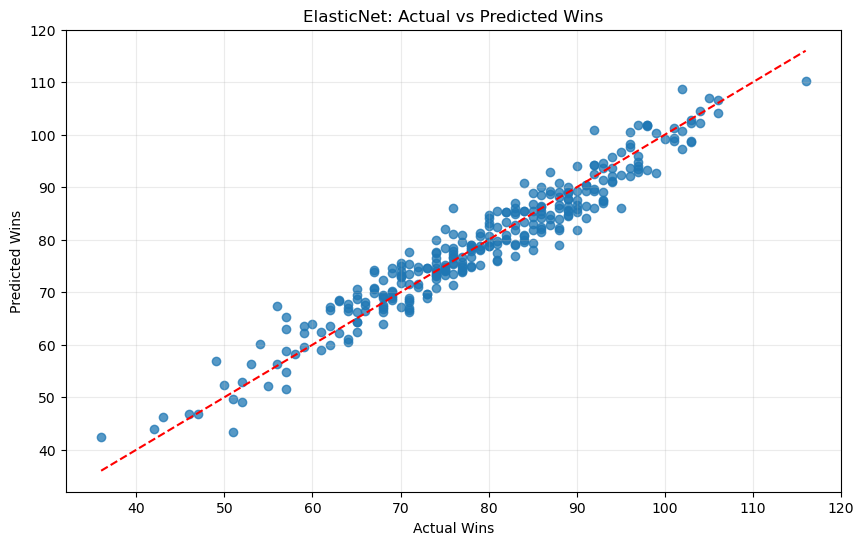

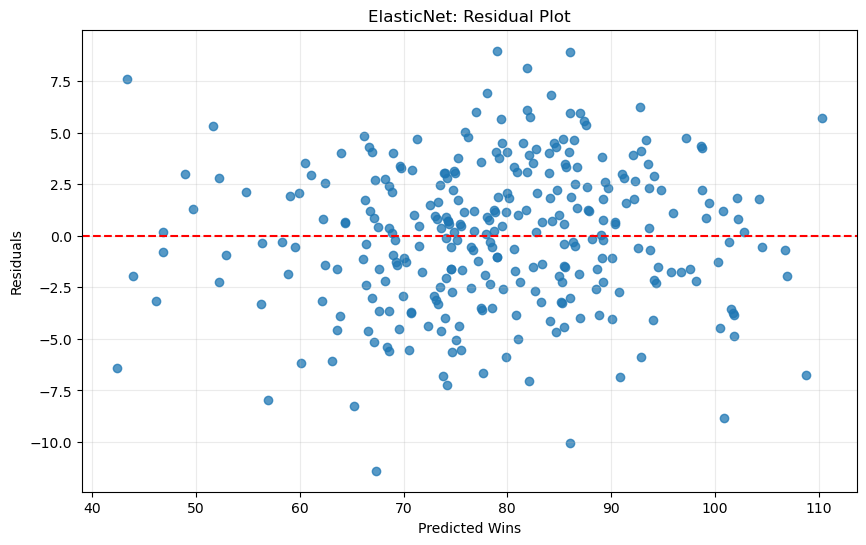

In [14]:
# Diagnostic plots using the last validation fold

plt.figure(figsize=(10, 6))
plt.scatter(last_y_test, last_preds, alpha=0.75)
plt.plot([last_y_test.min(), last_y_test.max()], [last_y_test.min(), last_y_test.max()], "r--")
plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")
plt.title("ElasticNet: Actual vs Predicted Wins")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(10, 6))
residuals = last_y_test - last_preds
plt.scatter(last_preds, residuals, alpha=0.75)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Wins")
plt.ylabel("Residuals")
plt.title("ElasticNet: Residual Plot")
plt.grid(True, alpha=0.25)
plt.show()

In [15]:
# Predict on the scoring dataset and save outputs

predict_preds = model.predict(X_predict)

submission_df = pd.DataFrame({
    "ID": predict_df["ID"],
    "W": np.round(predict_preds).astype(int)
})

submission_path = DATA_DIR / "submission_predict_updated3.csv"
submission_df.to_csv(submission_path, index=False)

schema_payload = {
    "target": TARGET,
    "feature_columns": feature_cols,
    "safe_drop_columns": SAFE_DROP_COLUMNS,
    "excluded_columns": sorted(EXCLUDED_COLUMNS),
    "best_alpha": BEST_ALPHA,
    "best_l1_ratio": BEST_L1_RATIO,
    "cv_type": "TimeSeriesSplit",
    "cv_mae": float(np.mean(mae_scores)),
    "cv_rmse": float(np.mean(rmse_scores)),
    "cv_r2": float(np.mean(r2_scores)),
}

schema_path = DATA_DIR / "mlb_feature_schema_from_notebook.json"
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(schema_payload, f, indent=2)

print(f"Saved updated submission to: {submission_path}")
print(f"Saved schema to: {schema_path}")

display(submission_df.head())

Saved updated submission to: /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle/submission_predict_updated3.csv
Saved schema to: /home/s_sofian/dsai/module_03/dsai-m3-5m-data-3.4-supervised-learning-advanced/kaggle/mlb_feature_schema_from_notebook.json


,ID,W
0,1756,70
1,1282,74
2,351,84
3,421,87
4,57,94
